In [1]:
import numpy as np
import pickle
import time
import os
import sys

import few
from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timeonly

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("warning")

use_gpu = True
force_backend = "cuda12x"
dt = 10
T = 12/12

print(f"dt={dt}s, T={T}yr")

inspiral_kwargs = {"func": 'KerrEccEqFlux', "DENSE_STEPPING": 0, "include_minus_m": False}
amplitude_kwargs = {"force_backend": force_backend}
Ylm_kwargs = {"force_backend": force_backend}
sum_kwargs_comb = {"force_backend": force_backend, "pad_output": True}
sum_kwargs_sep  = {"force_backend": force_backend, "pad_output": True, "separate_modes": True}

print("Initializing waveform generators...")
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, frame='detector',
    inspiral_kwargs=inspiral_kwargs, amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs, sum_kwargs=sum_kwargs_comb, use_gpu=use_gpu
)
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, frame='detector',
    inspiral_kwargs=inspiral_kwargs, amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs, sum_kwargs=sum_kwargs_sep, use_gpu=use_gpu
)

gwf = GWfuncs.GravWaveAnalysis(T, dt)

# Source parameters
m1 = 1e6; m2 = 1e1; a = 0.7; p0 = 9; e0 = 0.4
xI0 = 1.0; dist = 1.8
qS = np.pi; phiS = 0.; qK = 0.; phiK = 0.
Phi_phi0 = 0.4; Phi_theta0 = 0.0; Phi_r0 = 0.5
params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)

n_vals = np.arange(-1, 6)
ell = 2

print("Initializing loglike_timeonly...")
loglike_obj = loglike_timeonly.LogLikeTimeOnly(
    params_star, waveform_gen_comb, gwf, verbose=False,
    waveform_gen_sep=waveform_gen_sep, ell=ell, n_vals=n_vals, M_mode=None
)

data_snr = float(gwf.rhostat(loglike_obj.signal))
print(f"SNR: {data_snr:.4f}")

# ── Load precomputed LHS to get best starting point ──────────────────────────
pkl_path = '/nfs/home/svu/e1498138/localgit/FEWNEW/work/search/precomputed_lhs_paris3_1yr_1e+05.pkl'
print(f"Loading precomputed LHS from {pkl_path}...")
with open(pkl_path, 'rb') as f:
    lhs_data = pickle.load(f)

lhs_phys       = lhs_data['lhs_phys']
log_densities  = lhs_data['log_densities']
cov_prior      = lhs_data['cov_posterior']   # paris2 posterior cov = defines ellipse
ellipse_lo     = lhs_data['ellipse_lo']
ellipse_hi     = lhs_data['ellipse_hi']

best_idx = np.argmax(log_densities)
p_max    = lhs_phys[best_idx].copy()
print(f"Best LHS seed: {p_max}  logden={log_densities[best_idx]:.4f}")

# ── Proposal covariance ───────────────────────────────────────────────────────
SCALE = 0.01
cov_prop = SCALE * cov_prior
print(f"cov_prop = {SCALE} * cov_prior (diag: {np.sqrt(np.diag(cov_prop))})")

# ── Loglike wrapper ───────────────────────────────────────────────────────────
def eval_loglike(phys_params):
    logm1, logm2, a_i, p0_i, e0_i = phys_params
    return loglike_obj(np.array([
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
    ]))

def in_prior(p):
    return np.all(p >= ellipse_lo) and np.all(p <= ellipse_hi)

dt=10s, T=1.0yr
Initializing waveform generators...
Initializing loglike_timeonly...
SNR: 14.0813
Loading precomputed LHS from /nfs/home/svu/e1498138/localgit/FEWNEW/work/search/precomputed_lhs_paris3_1yr_1e+05.pkl...
Best LHS seed: [6.01448138 1.00559399 0.73052065 8.82542789 0.39503829]  logden=2.6745
cov_prop = 0.01 * cov_prior (diag: [0.00092971 0.00052197 0.00191881 0.01102793 0.00039019])


In [ ]:
  import matplotlib.cm as cm

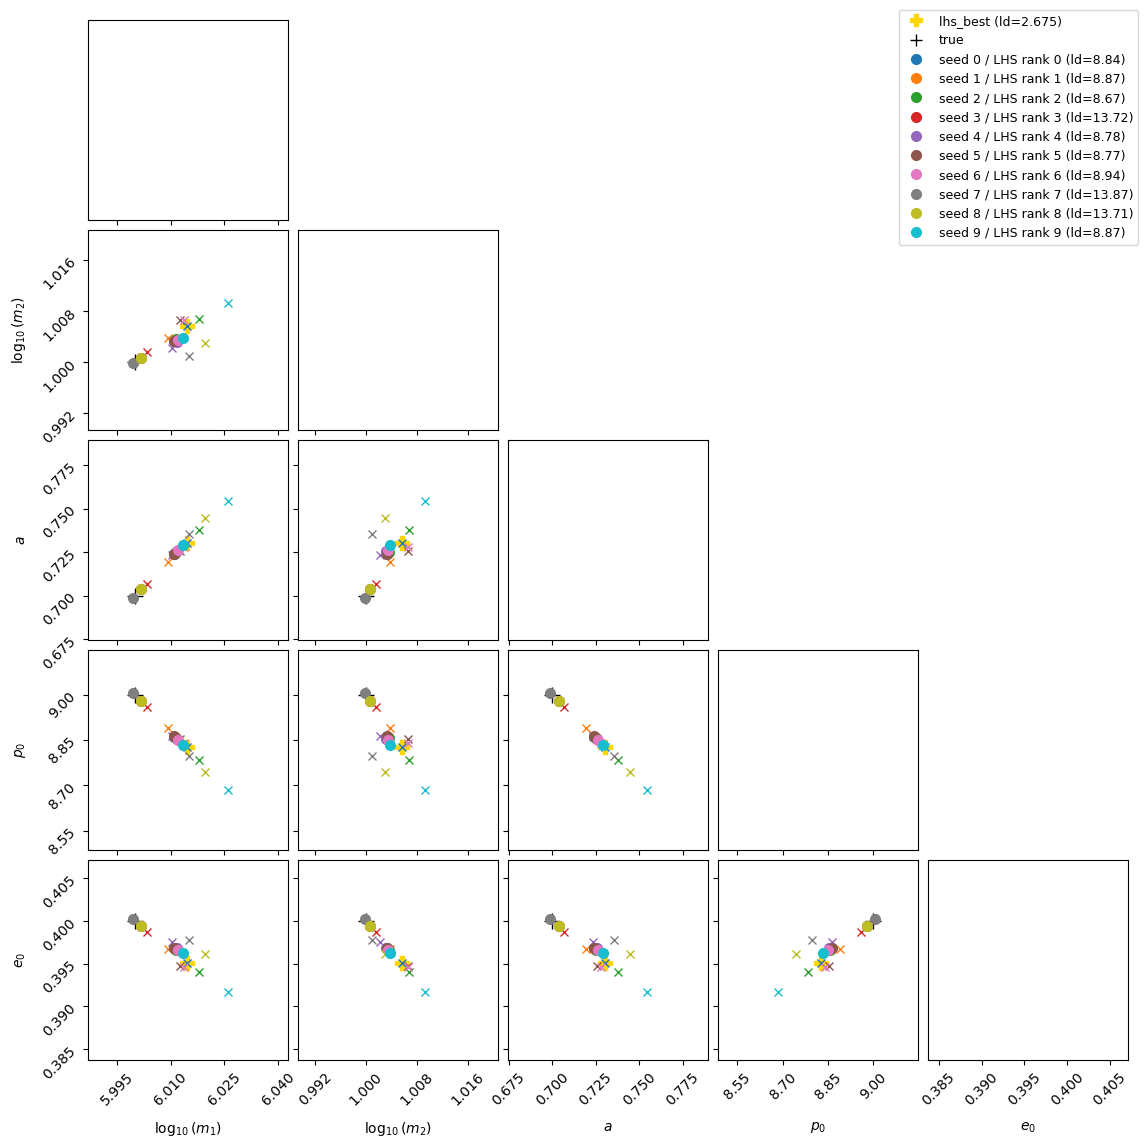

In [3]:
import corner
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

with open('/nfs/home/svu/e1498138/localgit/FEWNEW/work/search/precomputed_lhs_paris3_1yr_1e+05.pkl', 'rb') as f:
    lhs_data = pickle.load(f)

lhs_u      = lhs_data['lhs_u']
lhs_ld     = lhs_data['log_densities']
ellipse_lo = lhs_data['ellipse_lo']
ellipse_hi = lhs_data['ellipse_hi']

best_idx      = np.argmax(lhs_ld)
lhs_best_phys = ellipse_lo + (ellipse_hi - ellipse_lo) * lhs_u[best_idx]
true_params   = np.array([6.0, 1.0, 0.7, 9.0, 0.4])

greedy_pmaxs = np.array([
    [6.01106286, 1.0032367,  0.72406219, 8.86154496, 0.3967807 ],
    [6.01137716, 1.00336921, 0.72468811, 8.85906967, 0.39674246],
    [6.01154934, 1.00352219, 0.72502429, 8.85689865, 0.39660511],
    [6.00174168, 1.00064803, 0.70368594, 8.97868048, 0.3993892 ],
    [6.01173093, 1.00313848, 0.72566138, 8.85242258, 0.39680522],
    [6.01111106, 1.00333637, 0.72410561, 8.86272195, 0.39680748],                                                                                                                                                             
    [6.01203999, 1.00346121, 0.72617134, 8.85023148, 0.39660392],                                                                                                                                                             
    [5.99948812, 0.99982338, 0.69890616, 9.00647259, 0.40017727],                                                                                                                                                             
    [6.0016596,  1.00055986, 0.70356258, 8.97958344, 0.39946742],                                                                                                                                                             
    [6.01336014, 1.0037304,  0.7289997,  8.83332085, 0.39627624],                                                                                                                                                             
])                                                                                                                                                                                                                            
greedy_lds = np.array([8.838491, 8.867835, 8.673049, 13.722204, 8.779026,                                                                                                                                                     
                        8.774718, 8.937263, 13.868485, 13.714690, 8.867172])                                                                                                                                                   
                                                                                                                                                                                                                            
ndim   = 5                                                                                                                                                                                                                    
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                                                               
ranges = [(ellipse_lo[i], ellipse_hi[i]) for i in range(ndim)]                                                                                                                                                                
                                                                                                                                                                                                                            
lo  = np.array([r[0] for r in ranges])                                                                                                                                                                                        
hi  = np.array([r[1] for r in ranges])                                                                                                                                                                                        
mid = (lo + hi) / 2                                                                                                                                                                                                           
                
top10_idx = np.argsort(lhs_ld)[::-1][:10]                                                                                                                                                                                     
lhs_top10 = np.array([ellipse_lo + (ellipse_hi - ellipse_lo) * lhs_u[i] for i in top10_idx])
colors10  = plt.cm.tab10(np.linspace(0, 1, 10))                                                                                                                                                                               
                                                                                                                                                                                                                            
all_pts_padded = np.vstack([lhs_best_phys.reshape(1,-1), true_params.reshape(1,-1),                                                                                                                                           
                            greedy_pmaxs, lhs_top10,                                                                                                                                                                         
                            lo, hi, mid, (lo+mid)/2, (hi+mid)/2])                                                                                                                                                            
fig = corner.corner(all_pts_padded, labels=labels, show_titles=False,                                                                                                                                                         
                    plot_datapoints=False, plot_density=False,                                                                                                                                                                
                    plot_contours=False, ranges=ranges,                                                                                                                                                                       
                    hist_kwargs=dict(alpha=0, lw=0))                                                                                                                                                                          
                
corner.overplot_points(fig, lhs_best_phys.reshape(1,-1), color='gold',  marker='P', ms=10)                                                                                                                                    
corner.overplot_points(fig, true_params.reshape(1,-1),   color='black', marker='+', ms=12)
                                                                                                                                                                                                                            
for i, (lhs_pt, seed_pt, c) in enumerate(zip(lhs_top10, greedy_pmaxs, colors10)):
    corner.overplot_points(fig, lhs_pt.reshape(1,-1),  color=c, marker='x', ms=6)                                                                                                                                             
    corner.overplot_points(fig, seed_pt.reshape(1,-1), color=c, marker='o', ms=7)                                                                                                                                             
                                                                                                                                                                                                                            
axes = np.array(fig.axes[:ndim*ndim]).reshape((ndim, ndim))                                                                                                                                                                   
for row in range(ndim):                                                                                                                                                                                                       
    for col in range(ndim):
        if col <= row: axes[row, col].set_xlim(ranges[col])
        if col < row:  axes[row, col].set_ylim(ranges[row])                                                                                                                                                                   
                                                                                                                                                                                                                            
handles = [                                                                                                                                                                                                                   
    Line2D([0],[0], color='gold',  marker='P', ls='', ms=8, label=f'lhs_best (ld={lhs_ld[best_idx]:.3f})'),                                                                                                                   
    Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true'),                                                                                                                                                    
] + [Line2D([0],[0], color=colors10[i], marker='o', ls='', ms=7,
            label=f'seed {i} / LHS rank {i} (ld={greedy_lds[i]:.2f})')                                                                                                                                                        
    for i in range(10)]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=9)                                                                                                                                       
plt.show() 

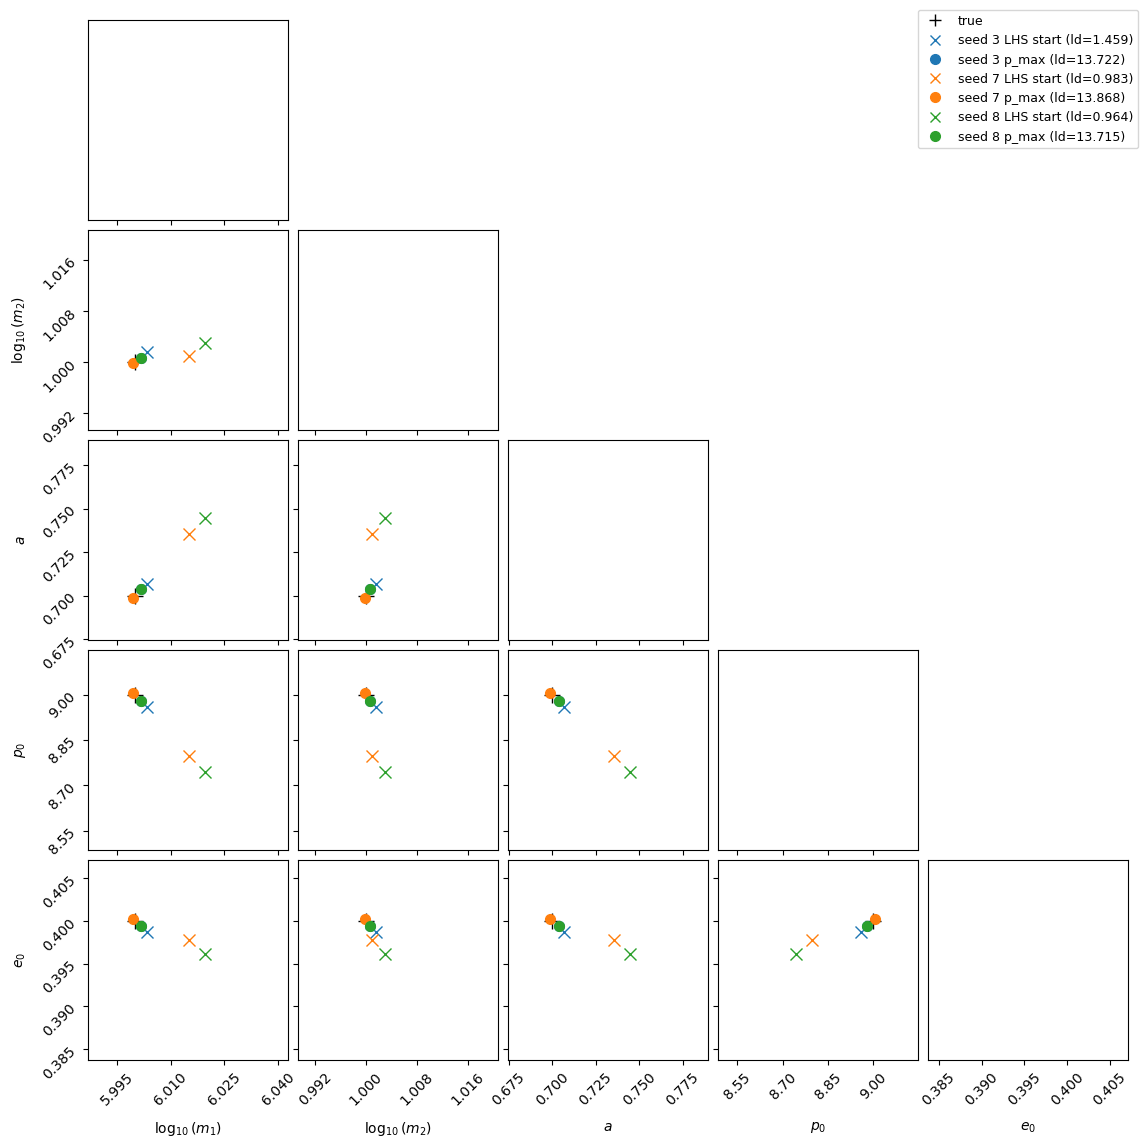

In [4]:
import corner                                                                                                                                                                                                               
import pickle                                                                                                                                                                                                                 
import numpy as np                                                                                                                                                                                                            
import matplotlib.pyplot as plt                                                                                                                                                                                               
from matplotlib.lines import Line2D                                                                                                                                                                                           
                                                                                                                                                                                                                            
with open('/nfs/home/svu/e1498138/localgit/FEWNEW/work/search/precomputed_lhs_paris3_1yr_1e+05.pkl', 'rb') as f:                                                                                                              
    lhs_data = pickle.load(f)
                                                                                                                                                                                                                            
lhs_u      = lhs_data['lhs_u']
lhs_ld     = lhs_data['log_densities']
ellipse_lo = lhs_data['ellipse_lo']                                                                                                                                                                                           
ellipse_hi = lhs_data['ellipse_hi']
                                                                                                                                                                                                                            
true_params  = np.array([6.0, 1.0, 0.7, 9.0, 0.4])                                                                                                                                                                            

greedy_pmaxs = np.array([                                                                                                                                                                                                     
    [6.01106286, 1.0032367,  0.72406219, 8.86154496, 0.3967807 ],
    [6.01137716, 1.00336921, 0.72468811, 8.85906967, 0.39674246],                                                                                                                                                             
    [6.01154934, 1.00352219, 0.72502429, 8.85689865, 0.39660511],
    [6.00174168, 1.00064803, 0.70368594, 8.97868048, 0.3993892 ],                                                                                                                                                             
    [6.01173093, 1.00313848, 0.72566138, 8.85242258, 0.39680522],                                                                                                                                                             
    [6.01111106, 1.00333637, 0.72410561, 8.86272195, 0.39680748],                                                                                                                                                             
    [6.01203999, 1.00346121, 0.72617134, 8.85023148, 0.39660392],                                                                                                                                                             
    [5.99948812, 0.99982338, 0.69890616, 9.00647259, 0.40017727],
    [6.0016596,  1.00055986, 0.70356258, 8.97958344, 0.39946742],                                                                                                                                                             
    [6.01336014, 1.0037304,  0.7289997,  8.83332085, 0.39627624],
])                                                                                                                                                                                                                            
greedy_lds = np.array([8.838491, 8.867835, 8.673049, 13.722204, 8.779026,
                        8.774718, 8.937263, 13.868485, 13.714690, 8.867172])                                                                                                                                                   
                
# LHS starting points: seed i starts from LHS rank i (sorted descending)                                                                                                                                                      
top10_idx = np.argsort(lhs_ld)[::-1][:10]
lhs_top10 = np.array([ellipse_lo + (ellipse_hi - ellipse_lo) * lhs_u[i] for i in top10_idx])                                                                                                                                  
                                                                                                                                                                                                                            
sel  = [3, 7, 8]
colors = ['tab:blue', 'tab:orange', 'tab:green']                                                                                                                                                                              
                                                                                                                                                                                                                            
ndim   = 5
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']                                                                                                                                               
ranges = [(ellipse_lo[i], ellipse_hi[i]) for i in range(ndim)]                                                                                                                                                                

lo  = np.array([r[0] for r in ranges])                                                                                                                                                                                        
hi  = np.array([r[1] for r in ranges])
mid = (lo + hi) / 2                                                                                                                                                                                                           
                
all_pts_padded = np.vstack([true_params.reshape(1,-1),                                                                                                                                                                        
                            greedy_pmaxs[sel], lhs_top10[sel],
                            lo, hi, mid, (lo+mid)/2, (hi+mid)/2])                                                                                                                                                            
fig = corner.corner(all_pts_padded, labels=labels, show_titles=False,                                                                                                                                                         
                    plot_datapoints=False, plot_density=False,
                    plot_contours=False, ranges=ranges,                                                                                                                                                                       
                    hist_kwargs=dict(alpha=0, lw=0))
                                                                                                                                                                                                                            
corner.overplot_points(fig, true_params.reshape(1,-1), color='black', marker='+', ms=12)                                                                                                                                      
                                                                                                                                                                                                                            
for i, (s, c) in enumerate(zip(sel, colors)):                                                                                                                                                                                 
    corner.overplot_points(fig, lhs_top10[s].reshape(1,-1),  color=c, marker='x', ms=8)
    corner.overplot_points(fig, greedy_pmaxs[s].reshape(1,-1), color=c, marker='o', ms=7)                                                                                                                                     
                                                                                                                                                                                                                            
axes = np.array(fig.axes[:ndim*ndim]).reshape((ndim, ndim))                                                                                                                                                                   
for row in range(ndim):                                                                                                                                                                                                       
    for col in range(ndim):
        if col <= row: axes[row, col].set_xlim(ranges[col])
        if col < row:  axes[row, col].set_ylim(ranges[row])                                                                                                                                                                   

handles = [Line2D([0],[0], color='black', marker='+', ls='', ms=8, label='true')]                                                                                                                                             
for s, c in zip(sel, colors):
    handles += [                                                                                                                                                                                                              
        Line2D([0],[0], color=c, marker='x', ls='', ms=7, label=f'seed {s} LHS start (ld={lhs_ld[top10_idx[s]]:.3f})'),
        Line2D([0],[0], color=c, marker='o', ls='', ms=7, label=f'seed {s} p_max (ld={greedy_lds[s]:.3f})'),                                                                                                                  
    ]                                                                                                                                                                                                                         
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98), fontsize=9)                                                                                                                                       
plt.show()

In [5]:
greedy_pmaxs[3],greedy_pmaxs[7], greedy_pmaxs[8]



(array([6.00174168, 1.00064803, 0.70368594, 8.97868048, 0.3993892 ]),
 array([5.99948812, 0.99982338, 0.69890616, 9.00647259, 0.40017727]),
 array([6.0016596 , 1.00055986, 0.70356258, 8.97958344, 0.39946742]))

In [6]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]


# seed 3

In [7]:
proc1_maxld_pt = greedy_pmaxs[3].reshape(1,-1)
proc1_maxld_pt

array([[6.00174168, 1.00064803, 0.70368594, 8.97868048, 0.3993892 ]])

In [8]:

def log_density(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a_i, p0_i, e0_i = params[i]

        try:
            loglike = loglike_obj(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf


        log_likes[i] = loglike
        # print(loglike)
    return log_likes

In [9]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [10]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


In [11]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


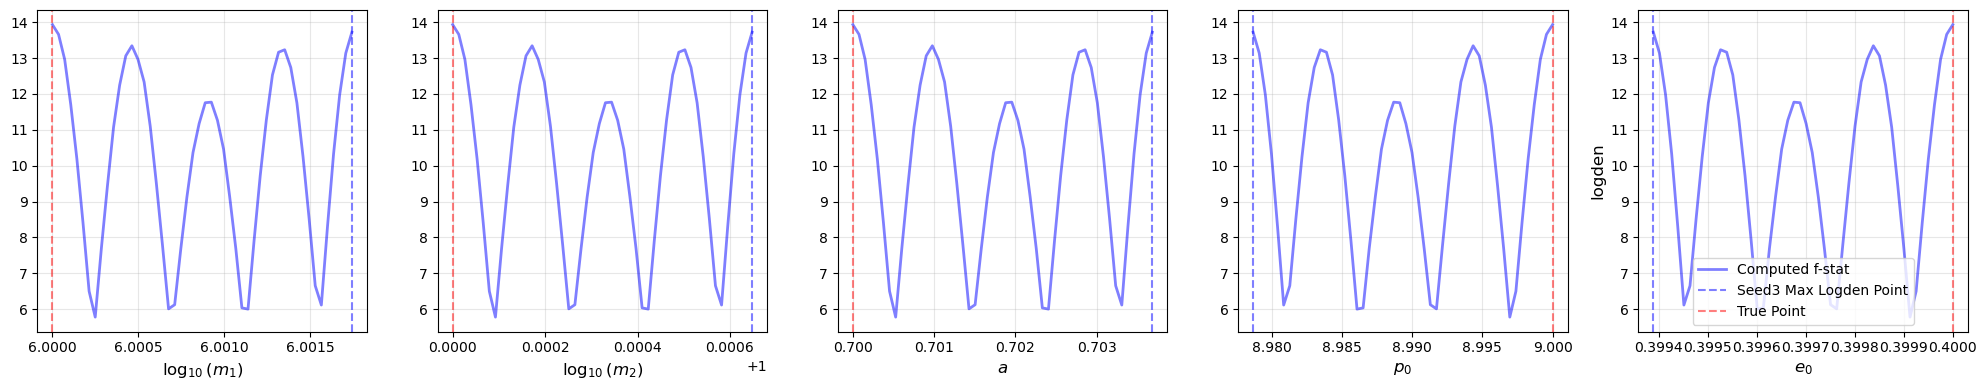

In [12]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Seed3 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [26]:
import loglike_pure                                                                                                                                                      
loglike_obj_pure = loglike_pure.LogLikePure(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None
)

In [27]:

def log_density_pure(params):
    params = np.asarray(params)
    n_samples = params.shape[0]
    log_likes = np.zeros(n_samples)

    for i in range(n_samples):
        logm1, logm2, a_i, p0_i, e0_i = params[i]

        try:
            loglike = loglike_obj_pure(np.array([
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0
            ]))
        except Exception:
            loglike = -np.inf


        log_likes[i] = loglike
        # print(loglike)
    return log_likes

In [28]:
logden_theory_proc1_pure = []
logden_theory_proc1_pure.append(log_density_pure(np.array(line_points_proc1).T))


In [30]:
logden_theory_proc1_pure = np.array(logden_theory_proc1_pure).flatten()


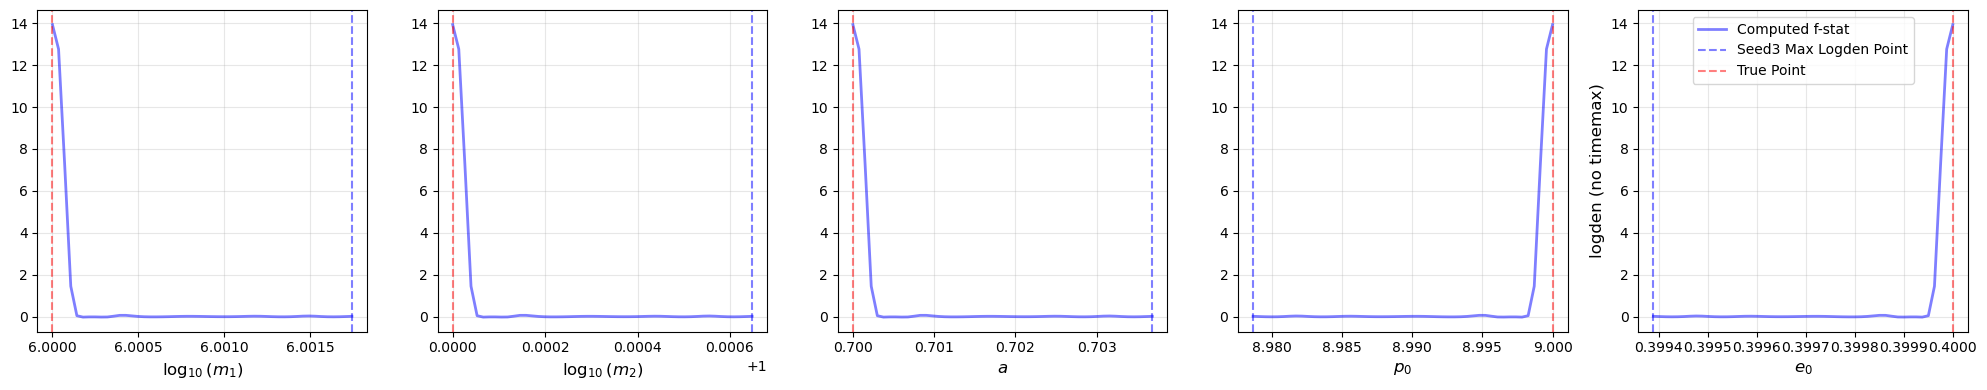

In [32]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden (no timemax)', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1_pure, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Seed3 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


# seed 7

In [42]:
proc2_maxld_pt = greedy_pmaxs[7].reshape(1,-1)
proc2_maxld_pt

array([[5.99948812, 0.99982338, 0.69890616, 9.00647259, 0.40017727]])

In [43]:
# connect two highest logden pts

proc2_maxld_pt_1d = proc2_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc2 = proc2_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc2_maxld_pt_1d)[:, np.newaxis]


In [44]:
logden_theory_proc2 = []
logden_theory_proc2.append(log_density(np.array(line_points_proc2).T))


In [45]:
logden_theory_proc2 = np.array(logden_theory_proc2).flatten()


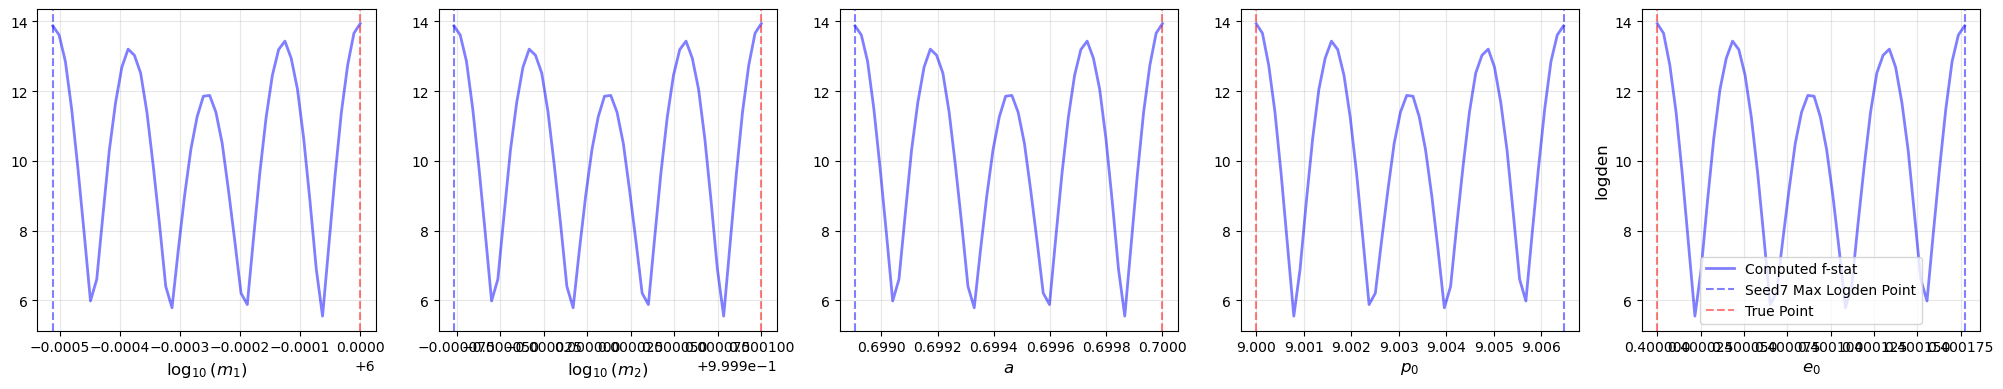

In [50]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc2[dim], logden_theory_proc2, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc2_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Seed7 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [33]:
logden_theory_proc2_pure = []
logden_theory_proc2_pure.append(log_density_pure(np.array(line_points_proc2).T))


In [34]:
logden_theory_proc2_pure = np.array(logden_theory_proc2_pure).flatten()


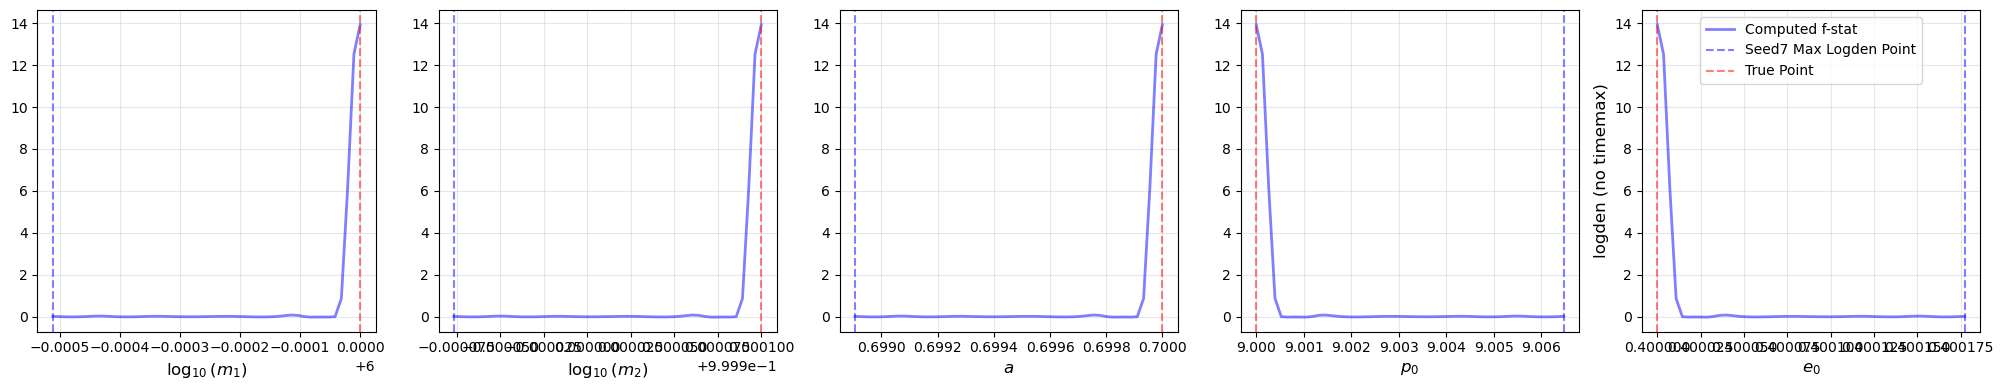

In [51]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden (no timemax)', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc2[dim], logden_theory_proc2_pure, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc2_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Seed7 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


# seed 8 

In [18]:
proc3_maxld_pt = greedy_pmaxs[8].reshape(1,-1)
proc3_maxld_pt

array([[6.0016596 , 1.00055986, 0.70356258, 8.97958344, 0.39946742]])

In [19]:
# connect two highest logden pts

proc3_maxld_pt_1d = proc3_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc3 = proc3_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc3_maxld_pt_1d)[:, np.newaxis]


In [20]:
logden_theory_proc3 = []
logden_theory_proc3.append(log_density(np.array(line_points_proc3).T))


In [55]:
logden_theory_proc3 = np.array(logden_theory_proc3).flatten()


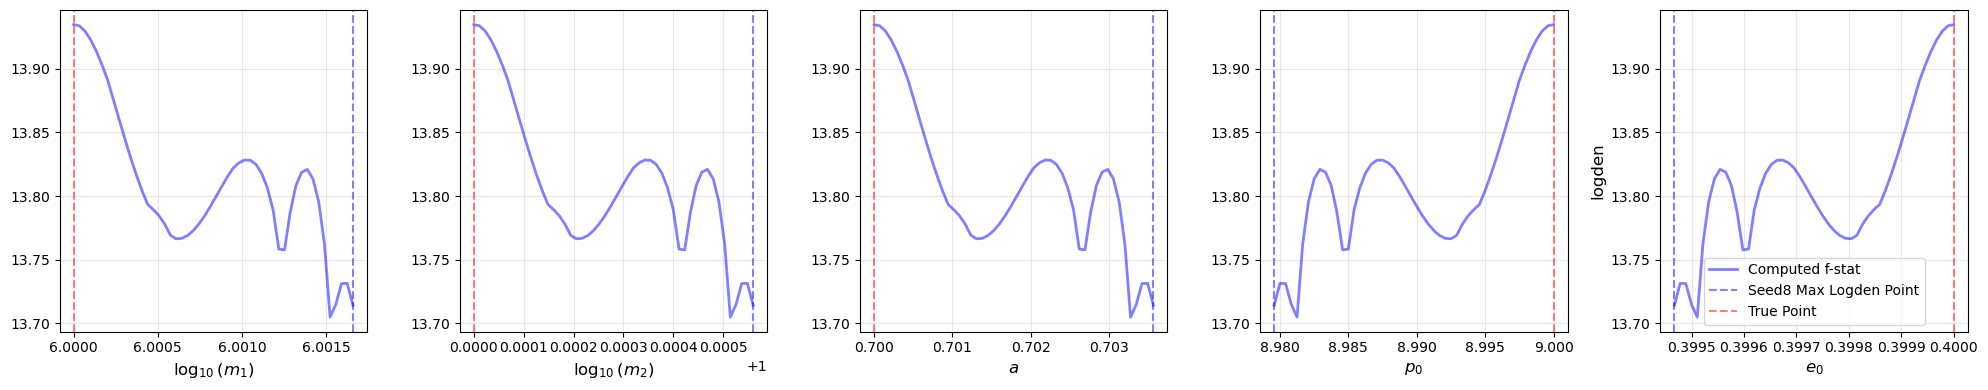

In [56]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc3[dim], logden_theory_proc3, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc3_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Seed8 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [38]:
logden_theory_proc3_pure = []
logden_theory_proc3_pure.append(log_density_pure(np.array(line_points_proc3).T))


In [39]:
logden_theory_proc3_pure = np.array(logden_theory_proc3_pure).flatten()


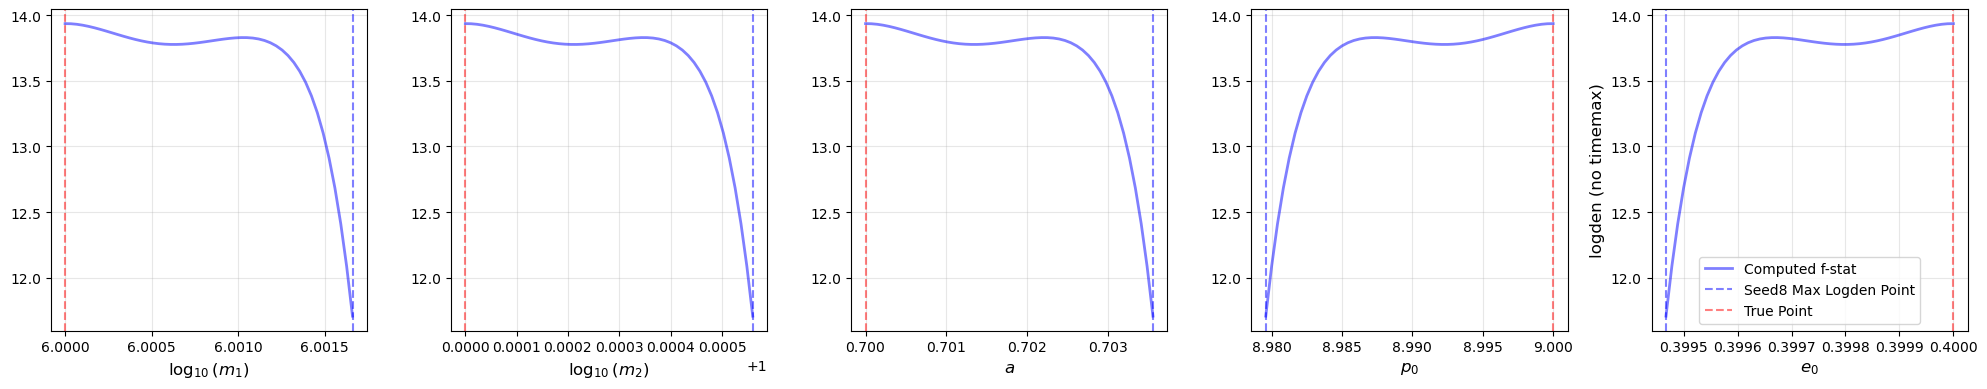

In [57]:
fig_1d, axs_1d = plt.subplots(1, 5, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
plt.ylabel('logden (no timemax)', fontsize=12)
for dim in range(5):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc3[dim], logden_theory_proc3_pure, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc3_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Seed8 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
